# AutoLabel
### Text-Prompt ile Otomatik Veri Seti Üretimi

**Pipeline:** `Grounding DINO` → `SAM 3 (SAM2)` → `Supervision`

| Özellik | Detay |
|---|---|
| Algılama | Grounding DINO (text-prompt ile nesne tespiti) |
| Segmentasyon | SAM2 (Segment Anything Model 2) |
| Desteklenen Formatlar | YOLOv8, COCO, Pascal VOC, CSV, TFRecord |
| Giriş | Google Drive veya yerel yükleme |



##Kurulum
Gerekli tüm kütüphaneler yüklenir. İlk çalıştırmada ~3-5 dakika sürebilir.

In [1]:
import subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f'HATA: {result.stderr[-500:]}')
    return result

print('[INFO]   Temel kütüphaneler yükleniyor...')
run('pip install -q supervision==0.25.0 transformers==4.40.0 timm einops')

print('[INFO]   Grounding DINO yükleniyor...')
run('pip install -q groundingdino-py')

print('[INFO]   SAM2 v2.1 yükleniyor...')
# SAM2.1 uyumluluğu için ana repodan güncel kurulum
run('pip install -q "git+https://github.com/facebookresearch/sam2.git"')

print('[INFO]   Ek araçlar yükleniyor...')
run('pip install -q Pillow opencv-python-headless tqdm')

print('[OK]     Tüm kütüphaneler hazır')

[INFO]   Temel kütüphaneler yükleniyor...
[INFO]   Grounding DINO yükleniyor...
[INFO]   SAM2 v2.1 yükleniyor...
[INFO]   Ek araçlar yükleniyor...
[OK]     Tüm kütüphaneler hazır


## Model Ağırlıklarını İndir

In [2]:
import os
from pathlib import Path

WEIGHTS_DIR = Path('/content/weights')
WEIGHTS_DIR.mkdir(exist_ok=True)

# --- Grounding DINO Weights ---
GDINO_CONFIG_PATH = WEIGHTS_DIR / 'GroundingDINO_SwinT_OGC.py'
GDINO_CKPT_PATH  = WEIGHTS_DIR / 'groundingdino_swint_ogc.pth'

if not GDINO_CKPT_PATH.exists():
    print('[INFO]   Grounding DINO ağırlıkları indiriliyor...')
    run(f'wget -q -O {GDINO_CKPT_PATH} https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth')
    run(f'wget -q -O {GDINO_CONFIG_PATH} https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py')
    print('[OK]     Grounding DINO hazır.')
else:
    print('[OK]     Grounding DINO ağırlıkları mevcut.')

# --- SAM2 Weights ---
SAM2_CKPT_PATH = WEIGHTS_DIR / 'sam2.1_hiera_large.pt'

if not SAM2_CKPT_PATH.exists():
    print('[INFO]   SAM2 ağırlıkları indiriliyor (~900MB)...')
    run(f'wget -q -O {SAM2_CKPT_PATH} https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt')
    print('[OK]     SAM2 hazır.')
else:
    print('[OK]     SAM2 ağırlıkları mevcut.')

print(f'\nAğırlık dosyaları: {WEIGHTS_DIR}')

[INFO]   Grounding DINO ağırlıkları indiriliyor...
[OK]     Grounding DINO hazır.
[INFO]   SAM2 ağırlıkları indiriliyor (~900MB)...
[OK]     SAM2 hazır.

Ağırlık dosyaları: /content/weights


##Modelleri Yükle

In [3]:
import torch
import numpy as np
import cv2
import supervision as sv
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Cihaz: {DEVICE.upper()}')
if DEVICE == 'cpu':
    print('[WARN]    GPU bulunamadı! İşlem çok yavaş olacak. Colab GPU ayarını kontrol edin.')

# ── Grounding DINO ──────────────────────────────────────────────
print('\n[INFO]   Grounding DINO yükleniyor...')
from groundingdino.util.inference import load_model as load_gdino, predict as gdino_predict

gdino_model = load_gdino(
    str(GDINO_CONFIG_PATH),
    str(GDINO_CKPT_PATH)
)
gdino_model = gdino_model.to(DEVICE)
print('[OK]     Grounding DINO hazır.')

# ── SAM2 ─────────────────────────────────────────────────────────
print('\n[INFO]   SAM2 yükleniyor...')
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SAM2.1 checkpoitları için 'sam2.1_hiera_l.yaml' kullanılmalıdır
sam2_model = build_sam2(
    config_file='configs/sam2.1/sam2.1_hiera_l.yaml',
    ckpt_path=str(SAM2_CKPT_PATH),
    device=DEVICE
)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print('[OK]     SAM2 hazır.')
print('\nTüm modeller yüklendi')

Cihaz: CUDA

[INFO]   Grounding DINO yükleniyor...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[OK]     Grounding DINO hazır.

[INFO]   SAM2 yükleniyor...
[OK]     SAM2 hazır.

Tüm modeller yüklendi


##Görselleri Yükle
**Seçenek A:** Google Drive'dan klasör bağla  
**Seçenek B:** Dosyaları doğrudan yükle

In [4]:
# ── Seçenek A: Google Drive ──────────────────────────────────────
USE_DRIVE = True  # True yaparak Drive'ı bağlayabilirsiniz

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ana klasörü tanımlıyoruz
    BASE_IMAGE_DIR = Path('/content/drive/MyDrive/uav_images')

# ── Seçenek B: Dosya Yükleme ─────────────────────────────────────
else:
    from google.colab import files
    print('Görsel dosyalarını seçin (JPG/PNG, çoklu seçim desteklenir):')
    uploaded = files.upload()

    BASE_IMAGE_DIR = Path('/content/input_images')
    BASE_IMAGE_DIR.mkdir(exist_ok=True)

    for fname, fdata in uploaded.items():
        (BASE_IMAGE_DIR / fname).write_bytes(fdata)

# ── Görselleri Tüm Alt Klasörlerde (group_1, group_2 vb.) Tara ────────
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
# rglob('*') kullanarak tüm alt klasörleri derinlemesine tarıyoruz
image_paths = sorted([p for p in BASE_IMAGE_DIR.rglob('*') if p.suffix.lower() in SUPPORTED_EXT])

print(f'\n[OK]     Toplam {len(image_paths)} görsel bulundu (tüm alt klasörler dahil):')
for p in image_paths[:10]:
    print(f'{p.relative_to(BASE_IMAGE_DIR)}')
if len(image_paths) > 10:
    print(f've {len(image_paths)-10} görsel daha')

Mounted at /content/drive

[OK]     Toplam 10327 görsel bulundu (tüm alt klasörler dahil):
group_1/1.jpg
group_1/10.jpg
group_1/100.jpg
group_1/1000.jpg
group_1/10000.jpg
group_1/10001.jpg
group_1/10002.jpg
group_1/10004.jpg
group_1/10005.jpg
group_1/10006.jpg
ve 10317 görsel daha


## Etiketleme Ayarları
Burası ana konfigürasyon hücresidir. Sadece bu hücreyi düzenleyin.

In [5]:
# ╔══════════════════════════════════════════════════════╗
# ║           KULLANICI AYARLARI — BURAYA BAKIN          ║
# ╚══════════════════════════════════════════════════════╝

# 1. Sınıf tanımları — virgülle ayırın
#    Örnekler: 'car . person . bicycle'
#              'tree . building . road'
#              'helmet . vest . glove'
CLASSES_TEXT = 'plane'

# 2. Hassasiyet modu
#    'bbox'    → Sadece Bounding Box (hızlı)
#    'segment' → Instance Segmentation (yüksek hassasiyet)
PRECISION_MODE = 'bbox'

# 3. Çıktı formatları — istediğinizi True yapın
EXPORT_YOLO   = True     # YOLOv8/v11 (.txt)
EXPORT_COCO   = False     # COCO JSON (.json)
EXPORT_VOC    = False    # Pascal VOC (.xml)
EXPORT_CSV    = False    # CSV (.csv)

# 4. Model hassasiyet eşikleri
BOX_THRESHOLD  = 0.45    # Nesne tespiti güven eşiği (0.0 - 1.0)
TEXT_THRESHOLD = 0.35    # Metin eşleşme eşiği (0.0 - 1.0)

# 5. Çıktı klasörü
OUTPUT_DIR = Path('/content/dataset')

# ─── Sınıfları parse et ─────────────────────────────────────────
CLASS_NAMES = [c.strip() for c in CLASSES_TEXT.split('.')]
CLASS_NAMES = [c for c in CLASS_NAMES if c]  # boşları temizle

print('Konfigürasyon Özeti:')
print(f'Sınıflar     : {", ".join(CLASS_NAMES)}')
print(f'Hassasiyet   : {PRECISION_MODE.upper()}')
print(f'Aktif Formatlar:')
if EXPORT_YOLO:  print('  YOLOv8/v11 (.txt)')
if EXPORT_COCO:  print('  COCO (.json)')
if EXPORT_VOC:   print('  Pascal VOC (.xml)')
if EXPORT_CSV:   print('  CSV (.csv)')

Konfigürasyon Özeti:
Sınıflar     : plane
Hassasiyet   : BBOX
Aktif Formatlar:
  YOLOv8/v11 (.txt)


## Ana Etiketleme Pipeline'ı
Tüm görseller işlenir, detections üretilir.

In [ ]:
from groundingdino.util.inference import load_image as load_gdino_image
from tqdm.notebook import tqdm
import json, time, gc, shutil, random

def detect_objects(image_path: Path):
    image_source, image_tensor = load_gdino_image(str(image_path))
    boxes, logits, phrases = gdino_predict(
        model=gdino_model, image=image_tensor, caption=CLASSES_TEXT,
        box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD, device=DEVICE
    )
    return image_source, boxes, logits, phrases

def phrase_to_class_id(phrase: str) -> int:
    phrase_lower = phrase.lower()
    for i, cls in enumerate(CLASS_NAMES):
        if cls.lower() in phrase_lower or phrase_lower in cls.lower(): return i
    return 0

# --- Hazırlık ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if EXPORT_YOLO:
    for split in ['train', 'val', 'test']:
        (OUTPUT_DIR / 'yolo' / split / 'images').mkdir(parents=True, exist_ok=True)
        (OUTPUT_DIR / 'yolo' / split / 'labels').mkdir(parents=True, exist_ok=True)

print(f'{len(image_paths)} görsel işleniyor ve bölünuyor (75/15/10)...\n')
start_time = time.time()
success_count = 0

for img_path in tqdm(image_paths, desc='İşleniyor'):
    try:
        image_source, boxes, logits, phrases = detect_objects(img_path)

        if hasattr(image_source, 'height'):
            h, w = image_source.height, image_source.width
        else:
            h, w = image_source.shape[:2]

        if len(boxes) > 0:
            # Split belirle
            rand = random.random()
            if rand < 0.75: split = 'train'
            elif rand < 0.90: split = 'val'
            else: split = 'test'

            if EXPORT_YOLO:
                shutil.copy2(img_path, OUTPUT_DIR / 'yolo' / split / 'images' / img_path.name)
                lines = []
                for box, phrase in zip(boxes, phrases):
                    cls_id = phrase_to_class_id(phrase)
                    lines.append(f"{cls_id} {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}")
                (OUTPUT_DIR / 'yolo' / split / 'labels' / f"{img_path.stem}.txt").write_text('\n'.join(lines))
            success_count += 1

        del image_source, boxes, logits; gc.collect()

    except Exception as e:
        print(f'Hata {img_path.name}: {e}')

print(f'\n[OK]     İşlem tamamlandı. Başarılı: {success_count}')

10327 görsel işleniyor ve bölünuyor (75/15/10)...



İşleniyor:   0%|          | 0/10327 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1051: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(arg

## Görsel Doğrulama
Rastgele seçilen görseller üzerinde etiketler görselleştirilir.

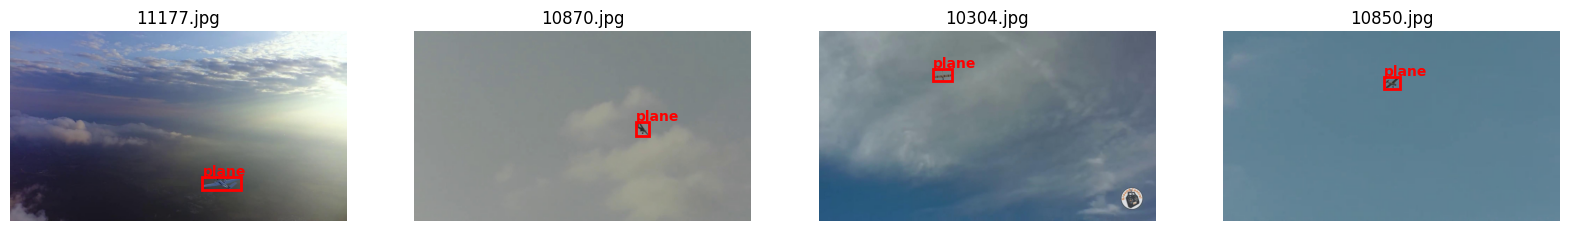

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image
import numpy as np

PREVIEW_COUNT = 4
yolo_images_dir = OUTPUT_DIR / 'yolo' / 'images'
yolo_labels_dir = OUTPUT_DIR / 'yolo' / 'labels'

# Etiketlenmiş görselleri bul
labeled_files = list(yolo_labels_dir.glob('*.txt'))
valid_labels = [f for f in labeled_files if f.stat().st_size > 0]

if not valid_labels:
    print('[WARN]   Hiçbir görselde nesne tespit edilemedi.')
else:
    sample_labels = random.sample(valid_labels, min(PREVIEW_COUNT, len(valid_labels)))
    fig, axes = plt.subplots(1, len(sample_labels), figsize=(20, 10))
    if len(sample_labels) == 1: axes = [axes]

    for idx, label_path in enumerate(sample_labels):
        img_path = yolo_images_dir / f'{label_path.stem}.jpg'
        if not img_path.exists(): img_path = yolo_images_dir / f'{label_path.stem}.png'

        img = Image.open(img_path)
        w, h = img.size
        axes[idx].imshow(img)

        content = label_path.read_text().strip()
        if content:
            labels = content.split('\n')
            for line in labels:
                parts = line.split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle((x1, y1), bw*w, bh*h, linewidth=2, edgecolor='red', facecolor='none')
                axes[idx].add_patch(rect)
                axes[idx].text(x1, y1-10, CLASS_NAMES[cls_id], color='red', weight='bold')

        axes[idx].set_title(img_path.name)
        axes[idx].axis('off')
    plt.show()

## İstatistik Raporu

In [13]:
from collections import Counter

yolo_labels_dir = OUTPUT_DIR / 'yolo' / 'labels'
label_files = list(yolo_labels_dir.glob('*.txt'))

stats = Counter()
imgs_with_det = 0

for f in label_files:
    content = f.read_text().strip()
    if content:
        imgs_with_det += 1
        for line in content.split('\n'):
            cls_id = int(line.split()[0])
            stats[CLASS_NAMES[cls_id]] += 1

print('='*30)
print('[INFO]   ETİKETLEME ÖZETİ')
print('='*30)
print(f'İşlenen toplam görsel: {len(image_paths)}')
print(f'Nesne bulunan görsel : {imgs_with_det}')
print(f'Boş görsel          : {len(image_paths) - imgs_with_det}')
print('\nSınıf Dağılımı:')
for cls, count in stats.items():
    print(f' - {cls}: {count} adet')
print('='*40)

📊 ETİKETLEME ÖZETİ
İşlenen toplam görsel: 2000
Nesne bulunan görsel : 1972
Boş görsel          : 28

Sınıf Dağılımı:
 - plane: 2066 adet


## Dataset Kaydetme

In [14]:
# ── Seçenek A: ZIP olarak indir ──────────────────────────────────
DOWNLOAD_MODE = 'drive'  # 'zip' veya 'drive'

if DOWNLOAD_MODE == 'zip':
    import zipfile
    from google.colab import files

    zip_path = Path('/content/autolabel_dataset.zip')
    print('[INFO]   ZIP oluşturuluyor...')

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fpath in OUTPUT_DIR.rglob('*'):
            if fpath.is_file():
                zf.write(fpath, fpath.relative_to(OUTPUT_DIR.parent))

    size_mb = zip_path.stat().st_size / 1024 / 1024
    print(f'[OK]     ZIP hazır: {size_mb:.1f} MB')
    files.download(str(zip_path))

# ── Seçenek B: Google Drive'a kaydet ────────────────────────────
elif DOWNLOAD_MODE == 'drive':
    import datetime
    if not Path('/content/drive').exists():
        from google.colab import drive
        drive.mount('/content/drive')

    # Tarih ve Sınıf ismini alarak klasör adı oluştur
    date_str = datetime.datetime.now().strftime('%Y%m%d_%H%M')
    folder_name = f'autolabel_{CLASSES_TEXT.replace(" . ", "_")}_{date_str}'
    drive_dest = Path(f'/content/drive/MyDrive/simurg_datasets/{folder_name}')

    if drive_dest.exists():
        shutil.rmtree(drive_dest)

    print(f'[INFO]   Veriler kopyalanıyor: {folder_name}...')
    shutil.copytree(OUTPUT_DIR, drive_dest)
    print(f'[OK]     Drive\'a kaydedildi: {drive_dest}')

📦 ZIP oluşturuluyor...
✅ ZIP hazır: 124.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>